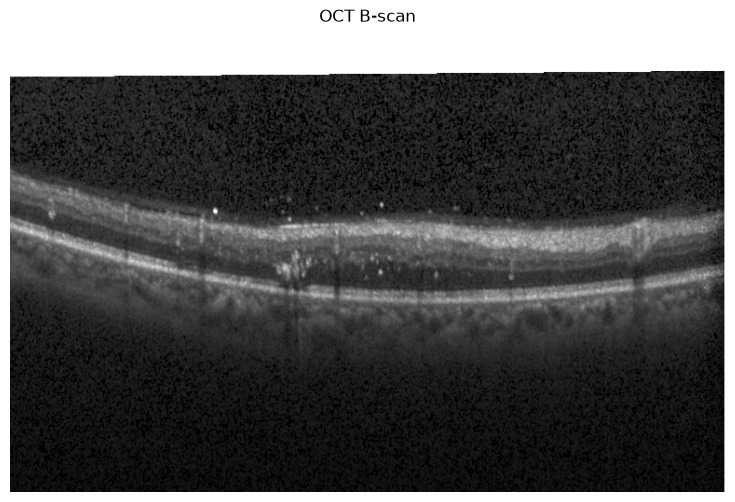

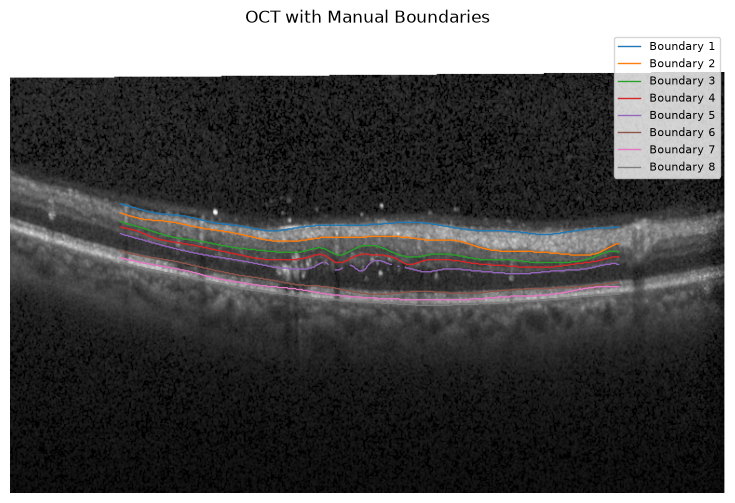

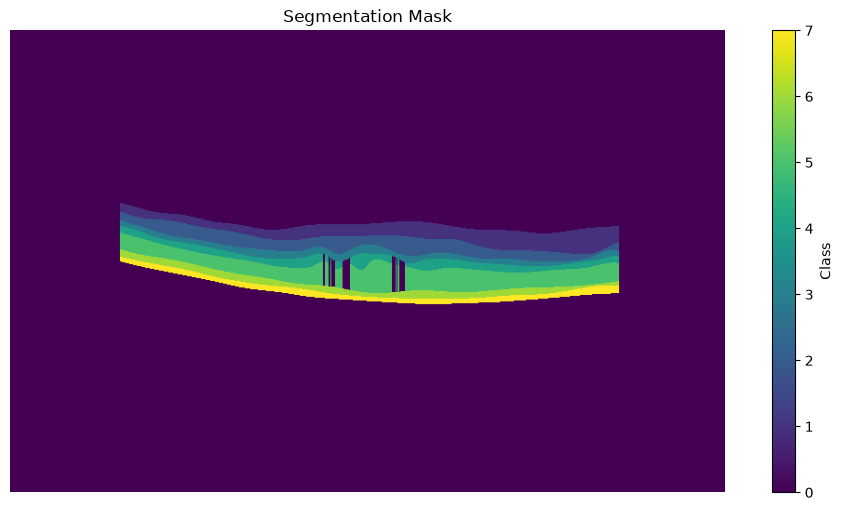

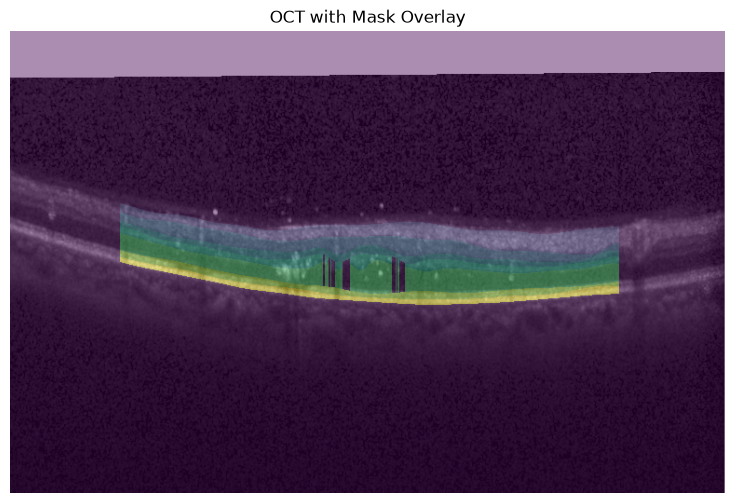

In [1]:
from pathlib import Path
import sys

current = Path.cwd().resolve()
repo_root = None
for candidate in [current, current.parent]:
    if (candidate / "src").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError("Could not find the project root containing the 'src' directory.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.io import load_subject
from src.masks import generate_mask
from src.visualization import show_oct, show_boundaries, show_mask, overlay_mask

subject = load_subject(repo_root / "datasets/duke/2015_BOE_Chiu/Subject_01.mat")

scan = 10
image = subject.images[:, :, scan]
boundaries = subject.manual_layers_1[:, :, scan]

show_oct(image)
show_boundaries(image, boundaries)

mask = generate_mask(boundaries, image.shape)
show_mask(mask)
overlay_mask(image, mask)

In [2]:
import numpy as np
from pathlib import Path
from src.io import load_dataset
from src.masks import generate_mask

DATA_DIR = repo_root / "datasets/duke/2015_BOE_Chiu"

subjects = load_dataset(DATA_DIR)

results = []

for subject in subjects:
    scans = subject.annotated_scans(grader=1)

    for scan in scans:
        boundaries = subject.manual_layers_1[:, :, scan]
        image_shape = subject.image_shape

        try:
            mask = generate_mask(boundaries, image_shape)
        except Exception as e:
            print(f"[CRASH] {subject.subject_id} scan {scan}: {e}")
            continue

        unique_classes = np.unique(mask)
        max_class = unique_classes.max()
        n_classes = len(unique_classes)

        results.append({
            "subject": subject.subject_id,
            "scan": scan,
            "n_classes": n_classes,
            "max_class": max_class,
            "classes": unique_classes.tolist(),
        })

        # Flag anything that doesn't look like a full 8-class mask (0-7)
        if n_classes < 8:
            print(f"[WARN] {subject.subject_id} scan {scan}: only {n_classes} classes -> {unique_classes.tolist()}")

print(f"\nChecked {len(results)} annotated scans across {len(subjects)} subjects.")

all_max = max(r["max_class"] for r in results)
all_min_classes = min(r["n_classes"] for r in results)
print(f"Max class value seen overall: {all_max}")
print(f"Fewest classes seen in a single scan: {all_min_classes}")


Checked 110 annotated scans across 10 subjects.
Max class value seen overall: 7
Fewest classes seen in a single scan: 8


In [3]:
for subject in subjects:
    for scan in subject.annotated_scans(grader=1):
        boundaries = subject.manual_layers_1[:, :, scan]
        mask = generate_mask(boundaries, subject.image_shape)

        for region in range(1, 8):
            thickness = np.sum(mask == region, axis=0)  # per-column pixel count
            valid_thickness = thickness[thickness > 0]
            if len(valid_thickness) == 0:
                continue
            if valid_thickness.mean() < 1.5:
                print(f"[THIN] {subject.subject_id} scan {scan} region {region}: "
                      f"mean thickness {valid_thickness.mean():.2f}px")

In [4]:
import torch
from src.models.double_conv import DoubleConv

block = DoubleConv(1, 64)

x = torch.randn(1, 1, 496, 768)

y = block(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([1, 1, 496, 768])
Output shape: torch.Size([1, 64, 496, 768])


In [5]:
import torch

from src.models.down_block import DownBlock

block = DownBlock(64, 128)

x = torch.randn(1, 64, 496, 768)

y = block(x)

print("Input :", x.shape)
print("Output:", y.shape)

Input : torch.Size([1, 64, 496, 768])
Output: torch.Size([1, 128, 248, 384])


In [7]:
import torch

from src.models.up_block import UpBlock

block = UpBlock(128, 64)

x = torch.randn(1, 128, 248, 384)

skip = torch.randn(1, 64, 496, 768)

print("Input :", x.shape)
print("Skip  :", skip.shape)

Input : torch.Size([1, 128, 248, 384])
Skip  : torch.Size([1, 64, 496, 768])


In [8]:
import torch

from src.models.unet import UNet

model = UNet(
    n_channels=1,
    n_classes=8,
)

x = torch.randn(1, 1, 496, 768)

y = model(x)

print("Input :", x.shape)
print("Output:", y.shape)

Input : torch.Size([1, 1, 496, 768])
Output: torch.Size([1, 8, 496, 768])


In [13]:
from torch.utils.data import DataLoader

from src.dataset import OCTLayerDataset

train_dataset = OCTLayerDataset(
    subjects= ["Subject_01", "Subject_02", "Subject_03", "Subject_04", "Subject_05",],
    grader=1,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)

AttributeError: 'str' object has no attribute 'annotated_scans'